## 1.1 Contents<a id='1.1_Contents'></a>
* [1 Exploratory Data Analysis (EDA)](#1_Exploratory_Data_Analysis_(EDA))
  * [1.1 Contents](#1.1_Contents)
  * [1.2 Introduction](#1.2_Introduction)
  * [1.3 Imports](#1.3_Imports)
  * [1.4 Load The Data](#1.4_Load_The_Data)
  * [1.5 Quality Checks](#1.5_Quality_Checks)
  * [1.6 Explore the Data](#1.5_Explore_the_Data)
    * [1.6.1 Aggregate Timestamps](#1.6.1_Aggregate_Timestamps)
    * [1.6.2 Visualize User Logins Data](#1.6.2_Visualize_User_Logins_Data)
      * [1.6.2.1 Time Series Plot](#1.6.2.1_Time_Series_Plot)
      * [1.6.2.2 Daily Logins Over Time](#1.6.2.2_Daily_Logins_Over_Time)
      * [1.6.2.3 Average_Daily_Cycle](#1.6.2.3_Average_Daily_Cycle)
      * [1.6.2.4 Heatmap_by_Date_Time_Bin](#1.6.2.4_Heatmap_by_Date_Time_Bin)
  * [1.7 Findings Summary](#1.7_Findings_Summary)

## 1.2 Introduction<a id='1.2_Introduction'></a>

Ultimate Technologies Inc. is a transportation network company that has disrupted the taxi and logistics industry and is considered to be one of the best companies in this sector.

For this exercise, the goal is to understand underlying user demand patterns for Ultimate Inc. transportation network company.

##### Inputs Provided
1. Timestamps of user logins in a particular geographic location.

##### Process to be Followed
1. Aggregate these login counts based on 15 minute time intervals
2. Visualize and describe the resulting time series of login counts in ways that best characterize the
underlying patterns of the demand.

##### Expected Output
1. Report/illustrate important features of the demand, such as daily cycles.
2. Report any data quality issues

Next, we will import the needed python packages and load the user logins json file mentioned above and begin exploring it.

## 1.3 Imports<a id='1.3_Imports'></a>

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

## 1.4 Load The Data<a id='1.4_Load_The_Data'></a>

Let's load the user logins data from the json file to a pandas dataframe.

In [2]:
login_df = pd.read_json('logins.json')

In [3]:
#Basic columns and total records information
login_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB


In [4]:
#Inspect First Few Rows of Dataframe to understand data being dealt with
login_df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


## 1.5 Data Quality Checks<a id='1.5_Data_Quality_Checks'></a>

In this section, data will be inspected for Nulls, Duplicates, Formatting, and any other data quality issues.

In [5]:
#Basic Stats regarding the data
login_df.describe()

,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


There are a total of 93,142 timetsamps spanning the period from Jan 1 to Apr 1.\
Since these are simulated dates, we will not focus on the year as actual year and hence will not classify weekdays vs. weekends.

In [6]:
#Lets sort the login_timestamps in ascending order
login_df = login_df.sort_values(by='login_time')

In [7]:
#Lets check for missing logins
login_df.isna().sum()

login_time    0
dtype: int64

Great! There seem to be no missing logins.

In [8]:
#Lets check for duplicated logins
login_df.duplicated().sum()

np.int64(877)

In [9]:
#lets look at the duplicated records
login_df[login_df.duplicated()].sort_values(by='login_time')

,login_time
354,1970-01-02 10:59:52
434,1970-01-02 12:27:48
506,1970-01-02 15:08:27
524,1970-01-02 16:14:36
675,1970-01-02 22:03:36
...,...
92034,1970-04-12 05:24:21
92367,1970-04-12 15:46:43
92438,1970-04-12 17:12:21
92986,1970-04-13 12:23:46


Only a small percentage of the total records have duplicates (<1%).\
In this case, there could be simultaneous logins so they may not be duplicates from the same user.\
Since, the percentage is extremely low, we will treat these as simultaneous logins from multiple users and not drop them from our data.

Next, we will inspect the time difference between these timestamps.

In [10]:
login_dft = login_df.copy()
login_dft['time_diff'] = login_dft['login_time'].diff()
print(login_dft.describe())

                          login_time                  time_diff
count                          93142                      93141
mean   1970-02-26 19:09:39.779648279  0 days 00:01:34.569759826
min              1970-01-01 20:12:16            0 days 00:00:00
25%       1970-02-04 10:37:19.750000            0 days 00:00:17
50%       1970-03-01 06:33:05.500000            0 days 00:00:45
75%       1970-03-22 04:01:10.750000            0 days 00:01:46
max              1970-04-13 18:57:38            0 days 01:31:41
std                              NaN  0 days 00:02:50.128176488


It looks like the maximum time gap between user logins is ~ 1 hour 32 mins and median time gap is just 45 seconds. This also tells us that no date in between our date range is missing.

In [11]:
#Checking for any null values for time difference
login_dft.isna().sum()

login_time    0
time_diff     1
dtype: int64

In [12]:
login_dft[login_dft['time_diff'].isna()]

,login_time,time_diff
6,1970-01-01 20:12:16,NaT


The one missing time difference it from the first record since there is nothing prior to it to get the difference from.

So, the data looks good. Let us proceed with the next step of exploring and visualizing it.

## 1.6 Explore The Data<a id='1.6_Explore_The_Data'></a>

In this section, we will explore the data further by aggregating timestamps in 15 min bins and also at day level. We will then visualize the user login patterns at the date level for all 4 months and average daily pattern observed throughout the time period.

### 1.6.1 Aggregate Time Stamps<a id='1.6.1_Aggregate_Time_Stamps'></a>

First, let's aggregate the timestamps in 15 minute interval bins.

In [13]:
login_df.set_index('login_time', inplace = True)
login_agg_15m = login_df.resample('15min').size()
login_agg_15m = login_agg_15m.fillna(0)

In [14]:
login_agg_15m.shape

(9788,)

In [15]:
login_agg_15m.describe()

count    9788.000000
mean        9.515938
std         8.328818
min         0.000000
25%         3.000000
50%         7.000000
75%        13.000000
max        73.000000
dtype: float64

It looks like there are a total of 9788 15 min bins. On an average each bin has a user login count of ~9.5 with max count of 73 and min count of 0.

Let us also aggregate the timestamps into daily level bins.

In [16]:
login_agg_daily = login_df.resample('D').size()
login_agg_daily= login_agg_daily.fillna(0)
rolling_7 = login_agg_daily.rolling(7, center = True, min_periods =4).mean()

In [17]:
login_agg_daily.shape

(103,)

In [18]:
login_agg_daily.describe()

count     103.000000
mean      904.291262
std       347.167463
min       112.000000
25%       643.000000
50%       827.000000
75%      1141.000000
max      1889.000000
dtype: float64

For the daily level aggregation, It looks like we have 103 days worth of data with the minimum daily user logins of 112, avg logins of ~ 904 and maximum of 1889.

### 1.6.2 Visualize User Logins Data<a id='1.6.2_Visualize_User_Logins_Data'></a>

In this section, we will plot the user logins data to identify user demand patterns.

#### 1.6.2.1 Time Series Plot<a id='1.6.2.1_Time_Series_Plot'></a>

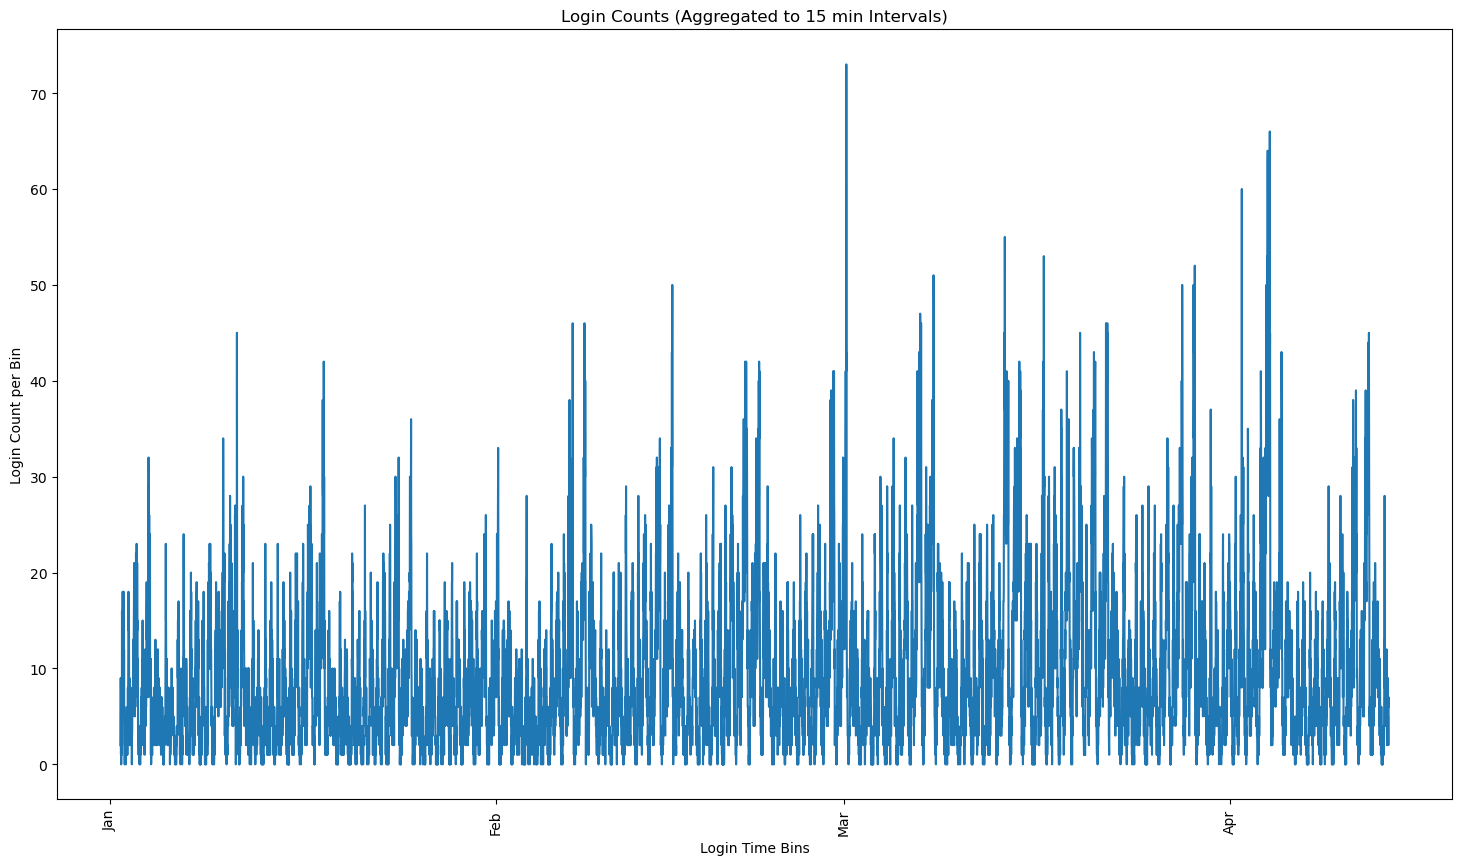

In [29]:
#Visualize time series with 15 min aggregation bin counts
fig, ax = plt.subplots(figsize=(18,10))
ax.plot(login_agg_15m.index, login_agg_15m.values)
plt.title("Login Counts (Aggregated to 15 min Intervals)")
plt.xlabel("Login Time Bins")
plt.ylabel("Login Count per Bin")
plt.xticks(rotation=90)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.show()

1. The plot shows a clear pattern with user activity peaking at certain times of the day.
2. Also, the login volumes show a general increasing trend from January to April.
3. To understand the user pattern better, let's aggregate it at the daily level and plot the data.

#### 1.6.2.2 Daily Logins Over Time<a id='1.6.2.2_Daily_Logins_Over_Time'></a>

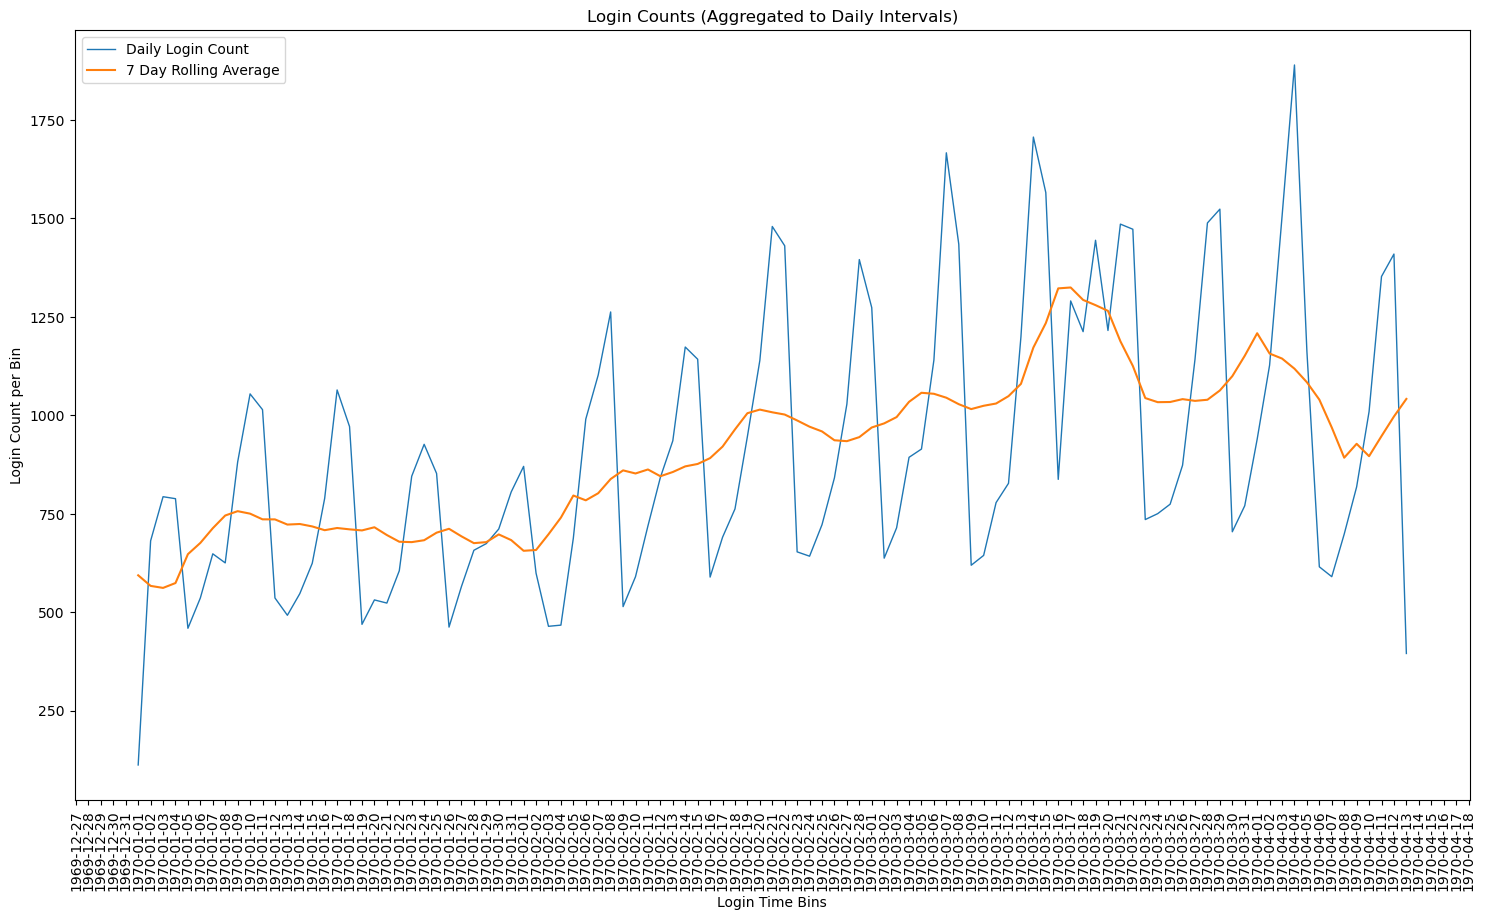

In [36]:
fig, ax = plt.subplots(figsize=(18,10))
ax.plot(login_agg_daily, linewidth = 1, label = 'Daily Login Count')
ax.plot(rolling_7, label = '7 Day Rolling Average')
ax.set_title("Login Counts (Aggregated to Daily Intervals)")
ax.set_xlabel("Login Time Bins")
ax.set_ylabel("Login Count per Bin")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.tick_params(axis = 'x', rotation = 90)
ax.legend()
plt.show()

1. The daily trend chart above (in blue) shows a clear oscillating weekly pattern suggesting certain days are busier than others during the week.
2. The rolling 7 trend line (in orange) overlayed on top of the daily trend time series also shows that user volume has more than doubled when comparing January with March/April data. This suggests in increase in demand for this service.

Next, we will inspect what an average daily user demand pattern looks like.

#### 1.6.2.3 Average Daily Cycle<a id='1.6.2.3_Average_Daily_Cycle'></a>

In [20]:
#Lets extract timestamps from the date time logins 
login_agg_15m = login_agg_15m.to_frame(name = 'count')
login_agg_15m['extracted_time'] = login_agg_15m.index.time

In [21]:
#Next, lets compute the average user login count during a particular time of the day
avg_daily_cycle = login_agg_15m.groupby('extracted_time')['count'].mean()
avg_daily_cycle.index = [et.hour + et.minute/60 for et in avg_daily_cycle.index]

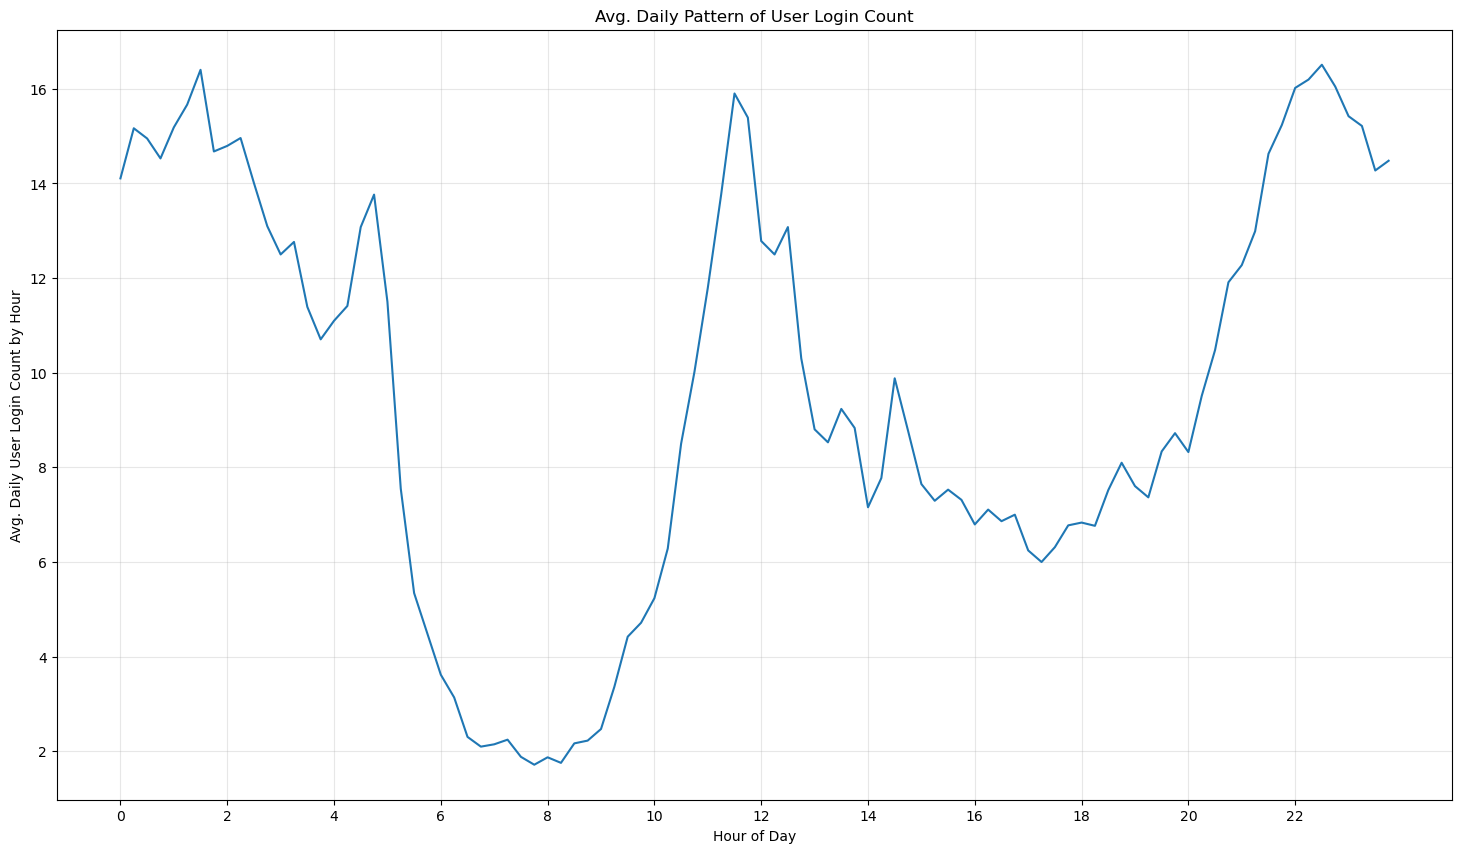

In [22]:
#Lets visualize the average daily trend
plt.figure(figsize=(18,10))
avg_daily_cycle.plot()
plt.title('Avg. Daily Pattern of User Login Count')
plt.xlabel('Hour of Day')
plt.ylabel('Avg. Daily User Login Count by Hour')
plt.xticks(range(0, 24, 2))
plt.grid(alpha = 0.3)
plt.show()

1. This avg. daily cycle visualization gives us a very insightful view into the daily user usage pattern.
2. It looks like the service is utilized heavily between midnight and early morning hours (~ 12 AM - 4:45 AM).
3. It dips heavily being least utilized between 6AM to 10AM and then peaks again around noon for a short time.
4. The dips again in the afternoon, however not as much as the morning dip and sustain itself at an avergae logins of 8 or so until 8PM.
5. It starts picking up again around 9PM and keeps trending up reaching and maintaining the peak after 11 PM all through the early morning hours.

This geographic location shows a lot of activity during night hours with morning hours being quiet and then the moderate activity begins again after noon reaching its peak at night.                                                                                         

#### 1.6.2.4 Heatmap by Date Time Bin<a id='1.6.2.4_Heatmap_by_Date_Time_Bin'></a>

We will look at the user activity during the whole 24 hour cycle in a more detailed way without averaging using the time stamp vs. all days from January to April using the heatmap below.

(96, 103)


<Axes: xlabel='date', ylabel='extracted_time'>

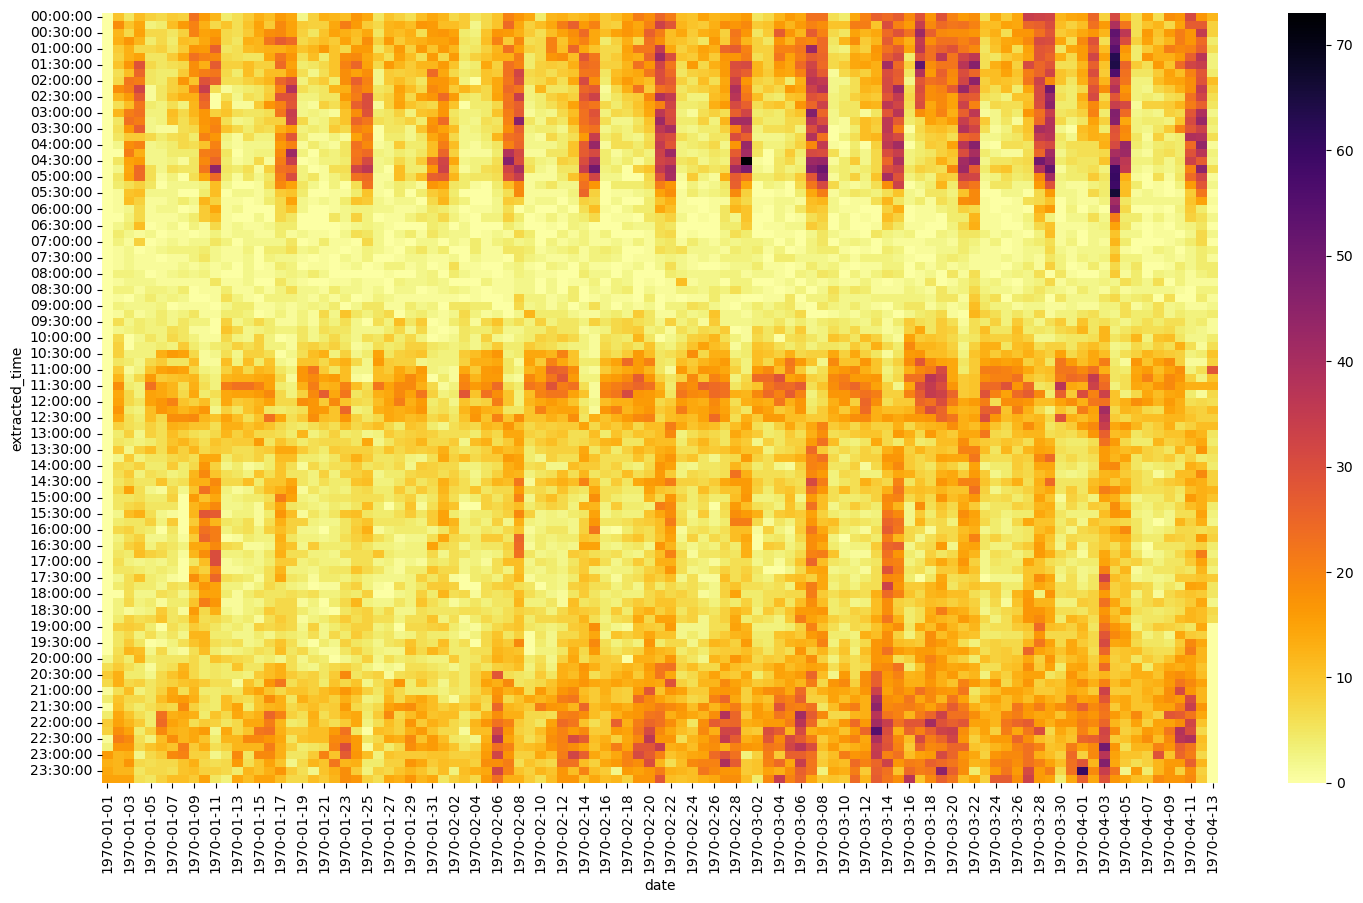

In [23]:
#heatmap
login_agg_15m['date'] = login_agg_15m.index.date
login_pivot = login_agg_15m.pivot_table(values = 'count', index = 'extracted_time', columns = 'date', fill_value=0)
print(login_pivot.shape)
plt.figure(figsize=(18,10))
sns.heatmap(login_pivot, cmap = 'inferno_r')

From the heatmap above, we see similar results as our avg. daily cycle and the weekly cycle all combined.

1. User activity has intensified since January all the way upto April.
2. Late night to Early morning hours seem to has the maximum user demand with also an equivalent peak around noon.
2. Certain days of the week seem to have a heavy demand with less demand for rest of the week days.
3. The nightly demand has also picked up since January intensifying around march with a positive usage trend.

## 1.7 Findings Summary<a id='1.7_Findings_Summary'></a>

#### Dataset overview
The dataset contains 93,142 user login timestamps for Ultimate Inc.'s transportation network service in a single geographic location, spanning 103 days (Jan 1 – Apr 13, simulated dates). Aggregated into 15-minute bins, this yields 9,788 intervals with an average of ~9.5 logins per bin (min 0, max 73). Aggregated daily, the average is ~904 logins/day (min 112, max 1,889).<p>
#### Data quality
•	No missing (null) timestamps.\
•	877 duplicated timestamps (<1% of records) interpreted as likely simultaneous logins from different users rather than data errors and retained rather than dropped.\
•	Time gaps between consecutive logins: median approx. 45 seconds, maximum ~1 hour 32 minutes — confirming there are no missing days or large gaps anywhere in the date range.\
•	Since the dates are simulated (year 1970), the notebook deliberately avoids labeling specific days as "weekday" vs. "weekend," treating any day-of-week pattern only as a recurring cycle rather than tied to real calendar meaning.<p>
#### Key demand patterns
##### 1.	Daily (intraday) cycle — the dominant pattern in the data:
•	Peak activity from midnight to ~ 4:45 AM.\
•	Sharp trough from 6 AM to 10 AM (quietest period of the day).\
•	A secondary, shorter peak around noon.\
•	A moderate, fairly flat afternoon (~8 logins/bin average) lasting until evening.\
•	Activity builds again from ~9 PM, climbing steadily into the overnight peak.\
•	Overall shape: heavy night-time/leisure-style usage, quiet mornings, and a modest midday bump — more consistent with nightlife/leisure travel than commuter/business traffic.<p>
##### 2.	Weekly cycle
The daily-level time series oscillates on a repeating cycle, with certain days consistently busier than others throughout the whole observation window (though not labeled as specific weekdays, per the caveat above).<p>
##### 3.	Overall growth trend
The 7-day rolling average on the daily series shows login volume more than doubling from January to March/April, indicating real growth in demand over the period, independent of the daily/weekly cycles.<p>
##### 4.	Heatmap (time-of-day × date) confirms all of the above simultaneously: 
The night-time and midday peaks recur across nearly every day in the dataset, a weekly rhythm is visible throughout, and the intensity of the overnight peak specifically appears to grow as the months progress — suggesting the overall growth in volume is concentrated disproportionately in the night-time peak rather than spread evenly across the day.<p>

#### Bottom line: 
Demand is characterized by a strong 24-hour cycle (night-time dominant, morning trough, midday bump), a recurring weekly rhythm, and a substantial upward trend in overall volume over the ~3.5-month window — with data quality good enough that these patterns can be read with confidence.<p>